# Week 9 — Gradient Boosting Regression

**Dataset:** Marketing and Product Performance (synthetic; 10,000 campaigns)  
**Week 9 objective:** Apply gradient boosting to continuous campaign revenue and evaluate learning rate, number of estimators, tree depth, and regularization.

This self-contained Week 9 submission follows the Week 8 evidence-first style. It tests whether the recorded campaign attributes contain generalizable revenue signal; it does not assume that a flexible model must produce a high score.

## 1. Analytical design

**Question.** Can gradient-boosted decision trees predict `Revenue_Generated` from the recorded campaign, product, customer, and promotional attributes?

**Why regression?** Revenue is continuous, so regression retains more information than a high-/lower-revenue label. Gradient boosting starts with a simple prediction and adds weak regression trees sequentially to reduce residual error.

**Safeguards.** One-of-a-kind ID columns are excluded. An 80/20 test set is held out before tuning; five-fold cross-validation is used only on training data. Shallow trees, minimum leaf sizes, subsampling, and learning-rate/estimator trade-offs act as regularization. This is a feasibility analysis, not a causal or pre-launch forecast.

### Step 1.1 — Import libraries and load the dataset

In [ ]:
# Standard-library configuration
import warnings

# Data analysis and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Gradient-boosting modeling and evaluation tools
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
RANDOM_STATE = 42

# Load the selected marketing and product performance dataset.
DATA_PATH = 'marketing_and_product_performance.csv'
df = pd.read_csv(DATA_PATH)

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
display(df.head())


Dataset shape: 10,000 rows × 17 columns


,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


### Data context

The loaded file contains **10,000 rows and 17 columns**, matching the dataset description. The fixed random seed makes the train/test split, cross-validation folds, and all visual outputs reproducible.


## 2. Data audit and EDA

Tree-based models do not require scaling because they split one variable at a time. They still require a defensible feature set. This audit checks completeness, removes unique identifiers, and examines revenue distribution and simple associations before modeling.

### Step 2.1 — Check data quality and define the modeling features

In [2]:
# Audit data quality before selecting predictors.
audit = pd.DataFrame(
    {
        'data_type': df.dtypes.astype(str),
        'missing_values': df.isna().sum(),
        'unique_values': df.nunique(),
    }
)
display(audit)

# Exclude one-of-a-kind IDs so the model cannot memorize individual records.
identifier_columns = [
    'Campaign_ID',
    'Product_ID',
    'Customer_ID',
    'Flash_Sale_ID',
    'Bundle_ID',
]

X = df.drop(columns=identifier_columns + ['Revenue_Generated'])
y = df['Revenue_Generated']

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

# Use descriptive feature-group names throughout the remaining analysis.
num = numeric_features
cat = categorical_features

print('Numeric features:')
print(numeric_features)
print()
print('Categorical features:')
print(categorical_features)
print()
print(f'Revenue mean: ${y.mean():,.2f}; standard deviation: ${y.std():,.2f}')


,data_type,missing_values,unique_values
Campaign_ID,str,0,10000
Product_ID,str,0,10000
Budget,float64,0,9995
Clicks,int64,0,4298
Conversions,int64,0,999
Revenue_Generated,float64,0,9997
ROI,float64,0,451
Customer_ID,str,0,10000
Subscription_Tier,str,0,3
Subscription_Length,int64,0,35


Numeric features:
['Budget', 'Clicks', 'Conversions', 'ROI', 'Subscription_Length', 'Discount_Level', 'Units_Sold', 'Bundle_Price', 'Customer_Satisfaction_Post_Refund']

Categorical features:
['Subscription_Tier', 'Common_Keywords']

Revenue mean: $50,038.63; standard deviation: $28,545.70


### Data-quality and feature-scope finding

The audit confirms there are no missing values. The five ID fields are unique for every record, so including them would allow the model to memorize labels rather than learn reusable relationships. After their removal, the model uses campaign, product, customer, and promotional descriptors only. This design tests whether those non-identifier variables contain generalizable revenue signal.


### Step 2.2 — Visualize the revenue target and simple associations

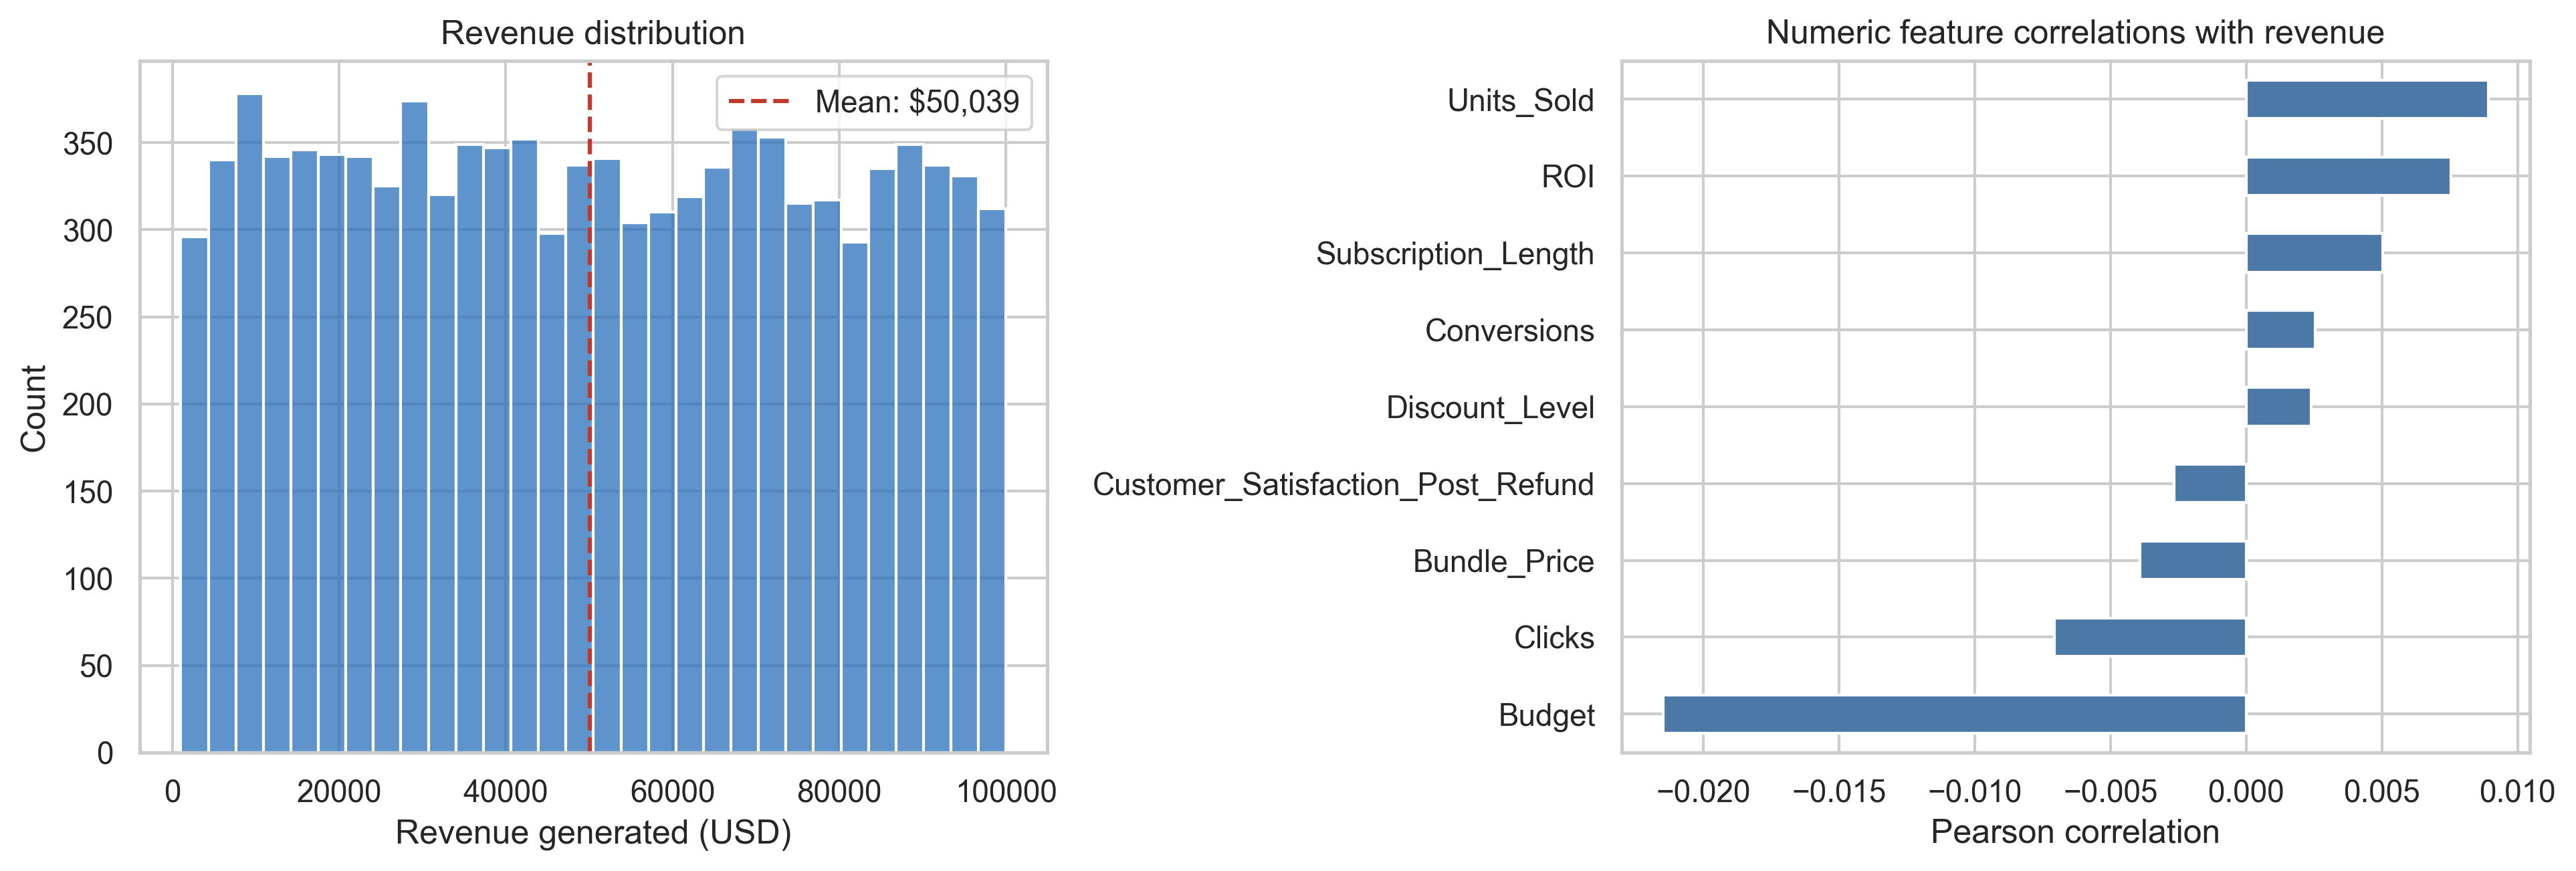

,correlation_with_revenue
Budget,-0.021
Clicks,-0.007
Bundle_Price,-0.004
Customer_Satisfaction_Post_Refund,-0.003
Discount_Level,0.002
Conversions,0.003
Subscription_Length,0.005
ROI,0.008
Units_Sold,0.009


In [3]:
# These plots establish the target distribution and a descriptive, not causal, expectation for modeling.

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(y, bins=30, color='#2A6FBB', ax=axes[0])
axes[0].axvline(y.mean(), color='#C0392B', ls='--', label=f'Mean: ${y.mean():,.0f}')
axes[0].set_title('Revenue distribution')
axes[0].set_xlabel('Revenue generated (USD)')
axes[0].legend()
corr = df[num + ['Revenue_Generated']].corr()['Revenue_Generated'].drop('Revenue_Generated').sort_values()
corr.plot(kind='barh', color='#4C78A8', ax=axes[1])
axes[1].set_title('Numeric feature correlations with revenue')
axes[1].set_xlabel('Pearson correlation')
plt.tight_layout()
plt.show()
display(corr.to_frame('correlation_with_revenue').style.format('{:.3f}'))


### EDA finding: weak simple revenue signal

The revenue distribution is broad, while the numeric correlations with revenue are near zero. Correlation cannot rule out nonlinear effects or interactions, which is why gradient boosting is still appropriate to test. However, the EDA establishes a cautious expectation: a complex model must outperform the mean-revenue baseline on held-out data before any practical predictive relationship can be claimed.


**EDA interpretation.** ID fields would allow memorization rather than reusable learning and are removed. Simple correlations do not detect every nonlinear pattern, but they set an important expectation: gradient boosting must demonstrate improvement on unseen campaigns before complex effects are interpreted as useful.

## 3. Gradient boosting and tuning plan

Gradient boosting builds trees **sequentially**. Each new weak learner fits residual error from the current ensemble. The key controls are: **learning rate** (size of each update), **number of estimators** (number of trees), **maximum depth** (tree complexity), `min_samples_leaf` (minimum records in a leaf), and `subsample` (fraction of rows used per tree).

The model below compares conservative and more flexible settings. It tunes by five-fold cross-validated RMSE, a dollar-denominated error metric that penalizes large revenue errors.

### Step 3.1 — Create the preprocessing pipeline and tune gradient boosting

In [4]:
# Tree models do not need numeric scaling; categorical variables are one-hot encoded for the regressor.

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', 'passthrough', num),
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore', sparse_output=False),
            cat,
        ),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'gbr',
            GradientBoostingRegressor(
                random_state=RANDOM_STATE,
                loss='squared_error',
            ),
        ),
    ]
)

# These configurations vary learning rate, tree count, depth, and regularization.
parameter_grid = [
    {
        'gbr__learning_rate': [0.03],
        'gbr__n_estimators': [100, 300],
        'gbr__max_depth': [1],
        'gbr__min_samples_leaf': [20],
        'gbr__subsample': [0.70],
    },
    {
        'gbr__learning_rate': [0.05],
        'gbr__n_estimators': [300],
        'gbr__max_depth': [2, 3],
        'gbr__min_samples_leaf': [20],
        'gbr__subsample': [0.70],
    },
    {
        'gbr__learning_rate': [0.10],
        'gbr__n_estimators': [100, 300],
        'gbr__max_depth': [2],
        'gbr__min_samples_leaf': [20],
        'gbr__subsample': [0.70],
    },
    {
        'gbr__learning_rate': [0.05],
        'gbr__n_estimators': [300],
        'gbr__max_depth': [2],
        'gbr__min_samples_leaf': [5, 20],
        'gbr__subsample': [1.00],
    },
]

cross_validation = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

search = GridSearchCV(
    estimator=pipeline,
    param_grid=parameter_grid,
    scoring='neg_root_mean_squared_error',
    cv=cross_validation,
    n_jobs=1,
    return_train_score=True,
)
search.fit(X_train, y_train)

results = pd.DataFrame(search.cv_results_)
results['cv_rmse'] = -results['mean_test_score']
results['train_rmse'] = -results['mean_train_score']

parameter_names = [
    'learning_rate',
    'n_estimators',
    'max_depth',
    'min_samples_leaf',
    'subsample',
]
for parameter_name in parameter_names:
    results[parameter_name] = results[f'param_gbr__{parameter_name}']

display_columns = parameter_names + ['cv_rmse', 'train_rmse']
display(
    results[display_columns]
    .sort_values('cv_rmse')
    .style.format({'cv_rmse': '${:,.0f}', 'train_rmse': '${:,.0f}'})
)

print('Best configuration:', search.best_params_)
print(f'Best mean CV RMSE: ${-search.best_score_:,.2f}')

# Keep concise aliases used in later visualization cells.
pre = preprocessor
pipe = pipeline
grid = parameter_grid
r = results


,learning_rate,n_estimators,max_depth,min_samples_leaf,subsample,cv_rmse,train_rmse
0,0.030000,100,1,20,0.700000,"$28,547","$28,473"
1,0.030000,300,1,20,0.700000,"$28,578","$28,400"
7,0.050000,300,2,20,1.000000,"$28,639","$27,831"
6,0.050000,300,2,5,1.000000,"$28,649","$27,812"
2,0.050000,300,2,20,0.700000,"$28,669","$27,728"
4,0.100000,100,2,20,0.700000,"$28,670","$27,970"
3,0.050000,300,3,20,0.700000,"$28,759","$26,734"
5,0.100000,300,2,20,0.700000,"$28,844","$27,182"


Best configuration: {'gbr__learning_rate': 0.03, 'gbr__max_depth': 1, 'gbr__min_samples_leaf': 20, 'gbr__n_estimators': 100, 'gbr__subsample': 0.7}
Best mean CV RMSE: $28,546.57


### Tuning and regularization finding

The search deliberately compares learning rate, tree count, depth, leaf size, and row subsampling. These controls balance bias and variance: smaller learning rates make gradual updates; more estimators add capacity; shallow depth and larger leaves limit overly specific splits; and subsampling injects randomness that can reduce variance. Five-fold cross-validation selects settings using training data only, preserving the 20% test set for one final unbiased evaluation.


### Step 3.2 — Compare cross-validated model configurations

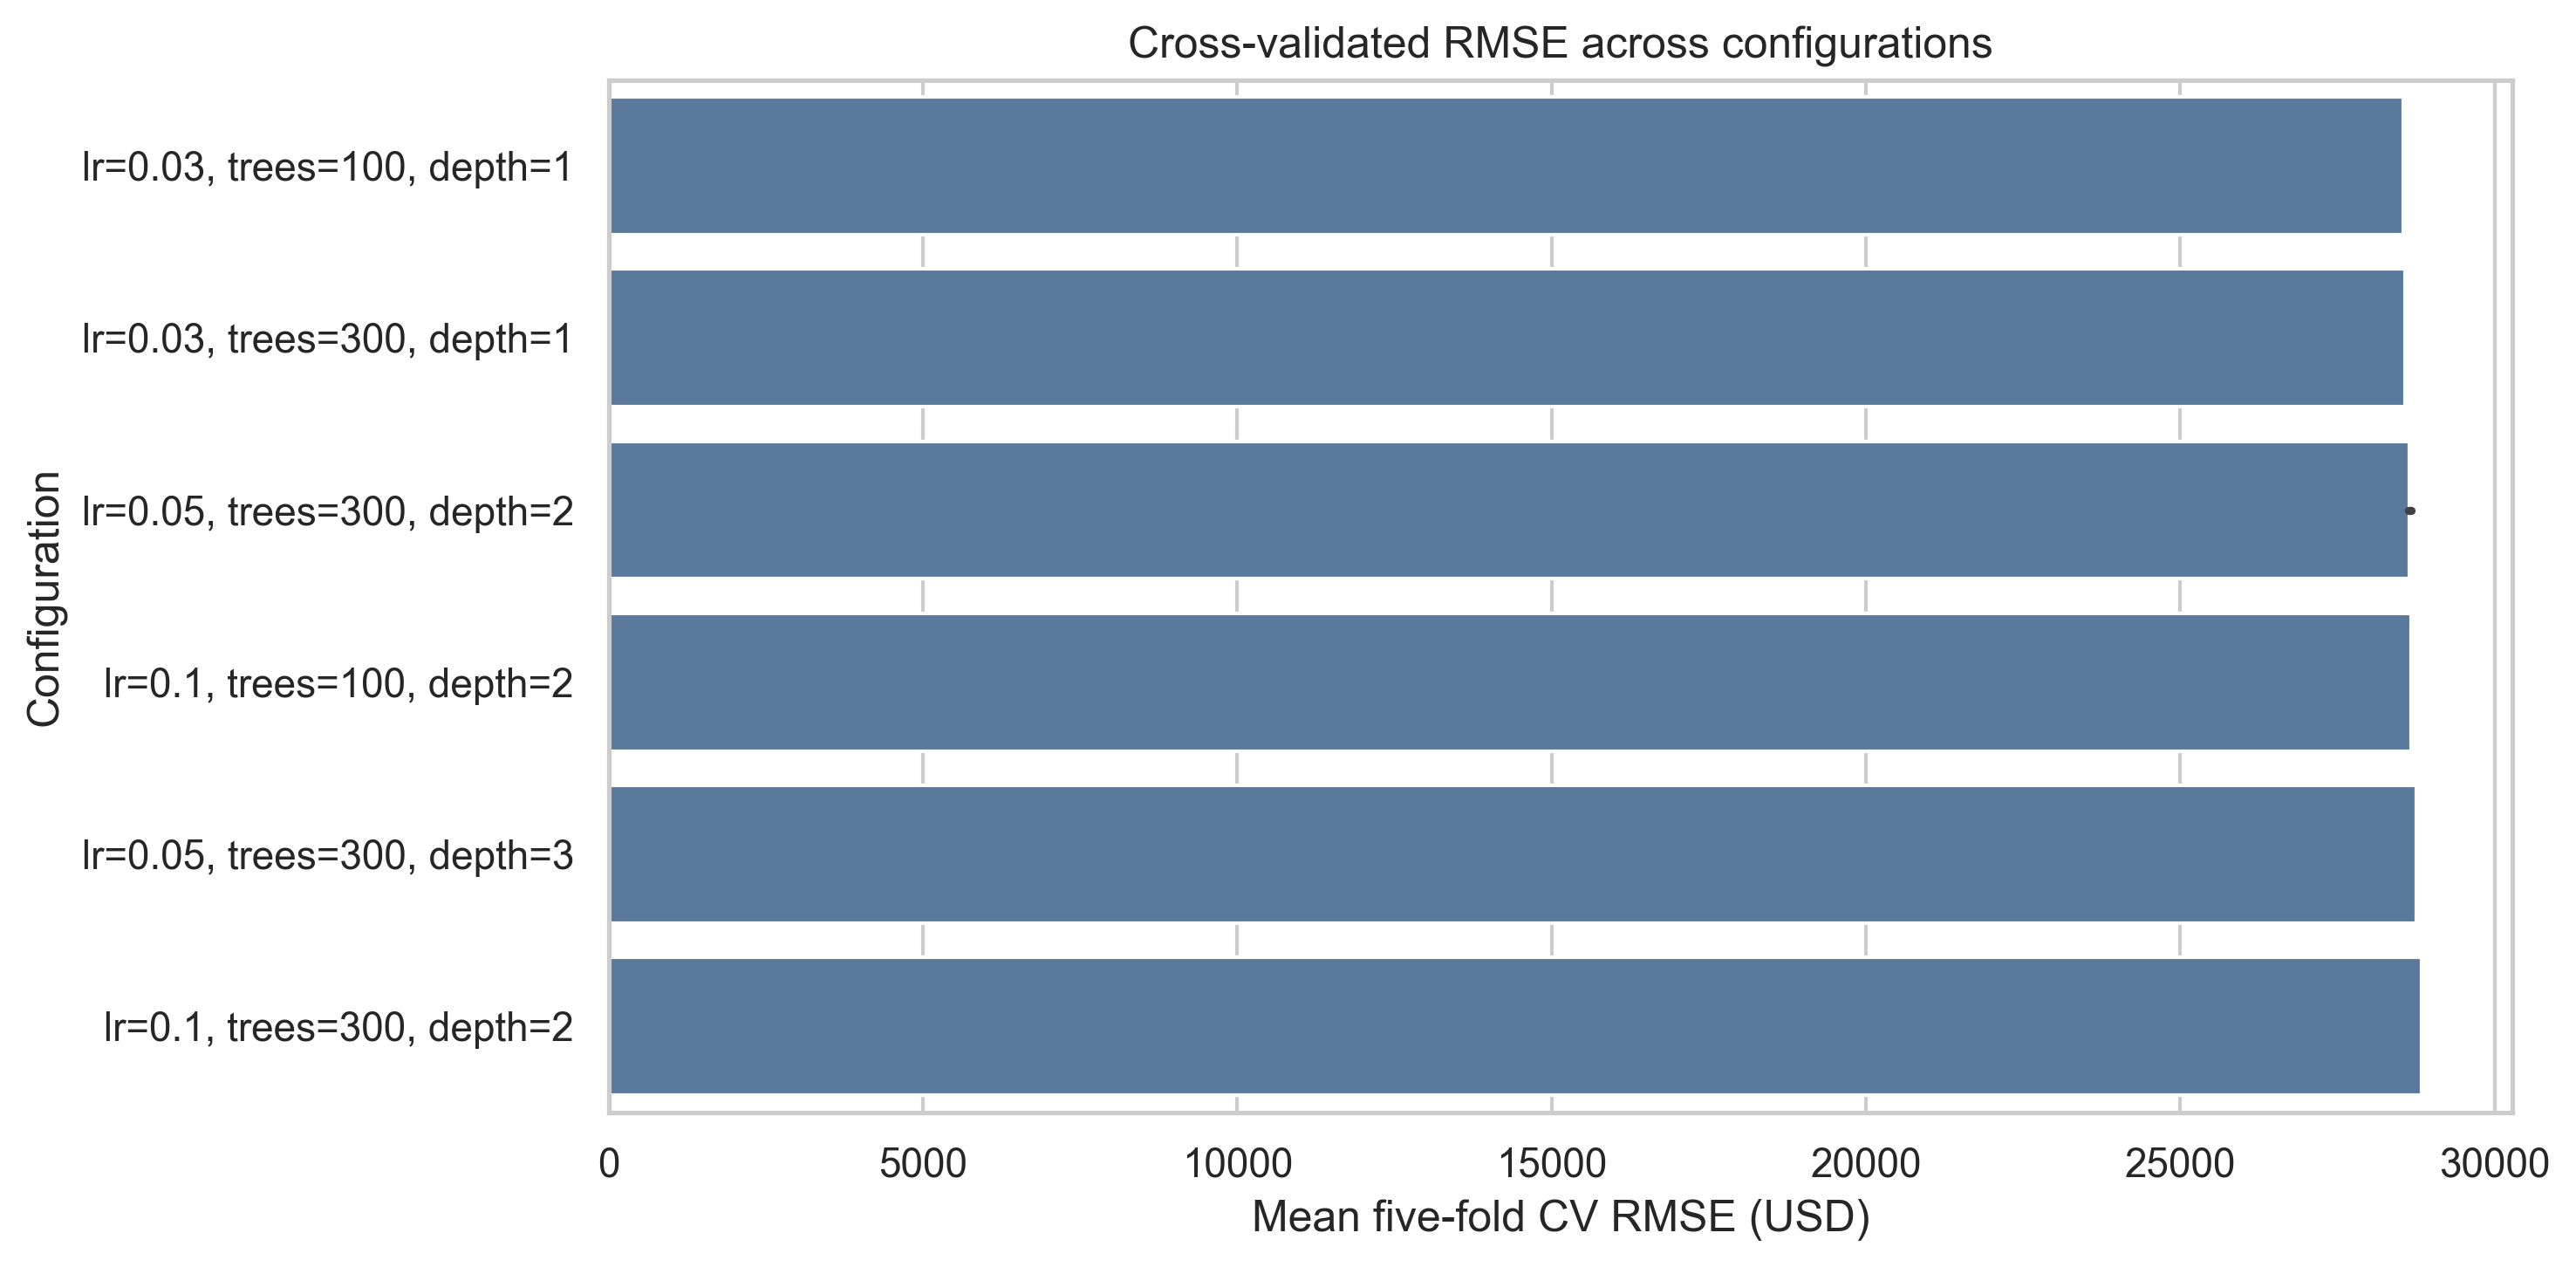

In [5]:
# Lower RMSE is better. This chart makes the regularization and complexity trade-offs visible.

p = r.sort_values('cv_rmse').copy()
p['configuration'] = 'lr=' + p.learning_rate.astype(str) + ', trees=' + p.n_estimators.astype(str) + ', depth=' + p.max_depth.astype(str)
plt.figure(figsize=(10, 5))
sns.barplot(data=p, x='cv_rmse', y='configuration', color='#4C78A8')
plt.title('Cross-validated RMSE across configurations')
plt.xlabel('Mean five-fold CV RMSE (USD)')
plt.ylabel('Configuration')
plt.tight_layout()
plt.show()


### Cross-validation interpretation

The lowest validation RMSE comes from the most conservative configuration: learning rate 0.03, 100 estimators, depth 1, minimum leaf size 20, and 70% subsampling. More flexible configurations do not produce a meaningful validation improvement. This is evidence that additional tree complexity is fitting variation in the training folds rather than uncovering stable revenue structure.


## 4. Held-out evaluation and overfitting evidence

The tuned model is evaluated once on the untouched test data and compared with a mean-revenue baseline. RMSE and MAE measure dollar error; R² measures improvement over predicting the mean. Training versus validation RMSE, plus staged errors as trees are added, show whether extra complexity generalizes.

### Step 4.1 — Evaluate the selected model on untouched test data

In [6]:
# Compare gradient boosting against a mean-revenue baseline using complementary regression metrics.

best = search.best_estimator_
pred = best.predict(X_test)
base = DummyRegressor(strategy='mean').fit(X_train, y_train).predict(X_test)

def scores(a, p):
    return {'RMSE': mean_squared_error(a, p) ** 0.5, 'MAE': mean_absolute_error(a, p), 'R2': r2_score(a, p)}
comparison = pd.DataFrame([{'model': 'Mean-revenue baseline', **scores(y_test, base)}, {'model': 'Tuned gradient boosting', **scores(y_test, pred)}])
display(comparison.style.format({'RMSE': '${:,.2f}', 'MAE': '${:,.2f}', 'R2': '{:.3f}'}))
best_row = r.loc[search.best_index_]
print(f"Mean training RMSE: ${best_row['train_rmse']:,.2f}")
print(f"Mean validation RMSE: ${best_row['cv_rmse']:,.2f}")


,model,RMSE,MAE,R2
0,Mean-revenue baseline,"$28,567.79","$24,717.33",-0.001
1,Tuned gradient boosting,"$28,567.27","$24,718.46",-0.001


Mean training RMSE: $28,472.86
Mean validation RMSE: $28,546.57


### Held-out evaluation: no improvement over baseline

On the untouched test set, tuned gradient boosting has RMSE **$28,567.27** and R² **−0.001**, essentially indistinguishable from the mean-revenue baseline RMSE of **$28,567.79**. A negative R² means the model does not improve on predicting the test-set mean. This is the most important model-feasibility result: the provided features do not support reliable revenue prediction in this dataset.


### Step 4.2 — Diagnose learning behavior and prediction error

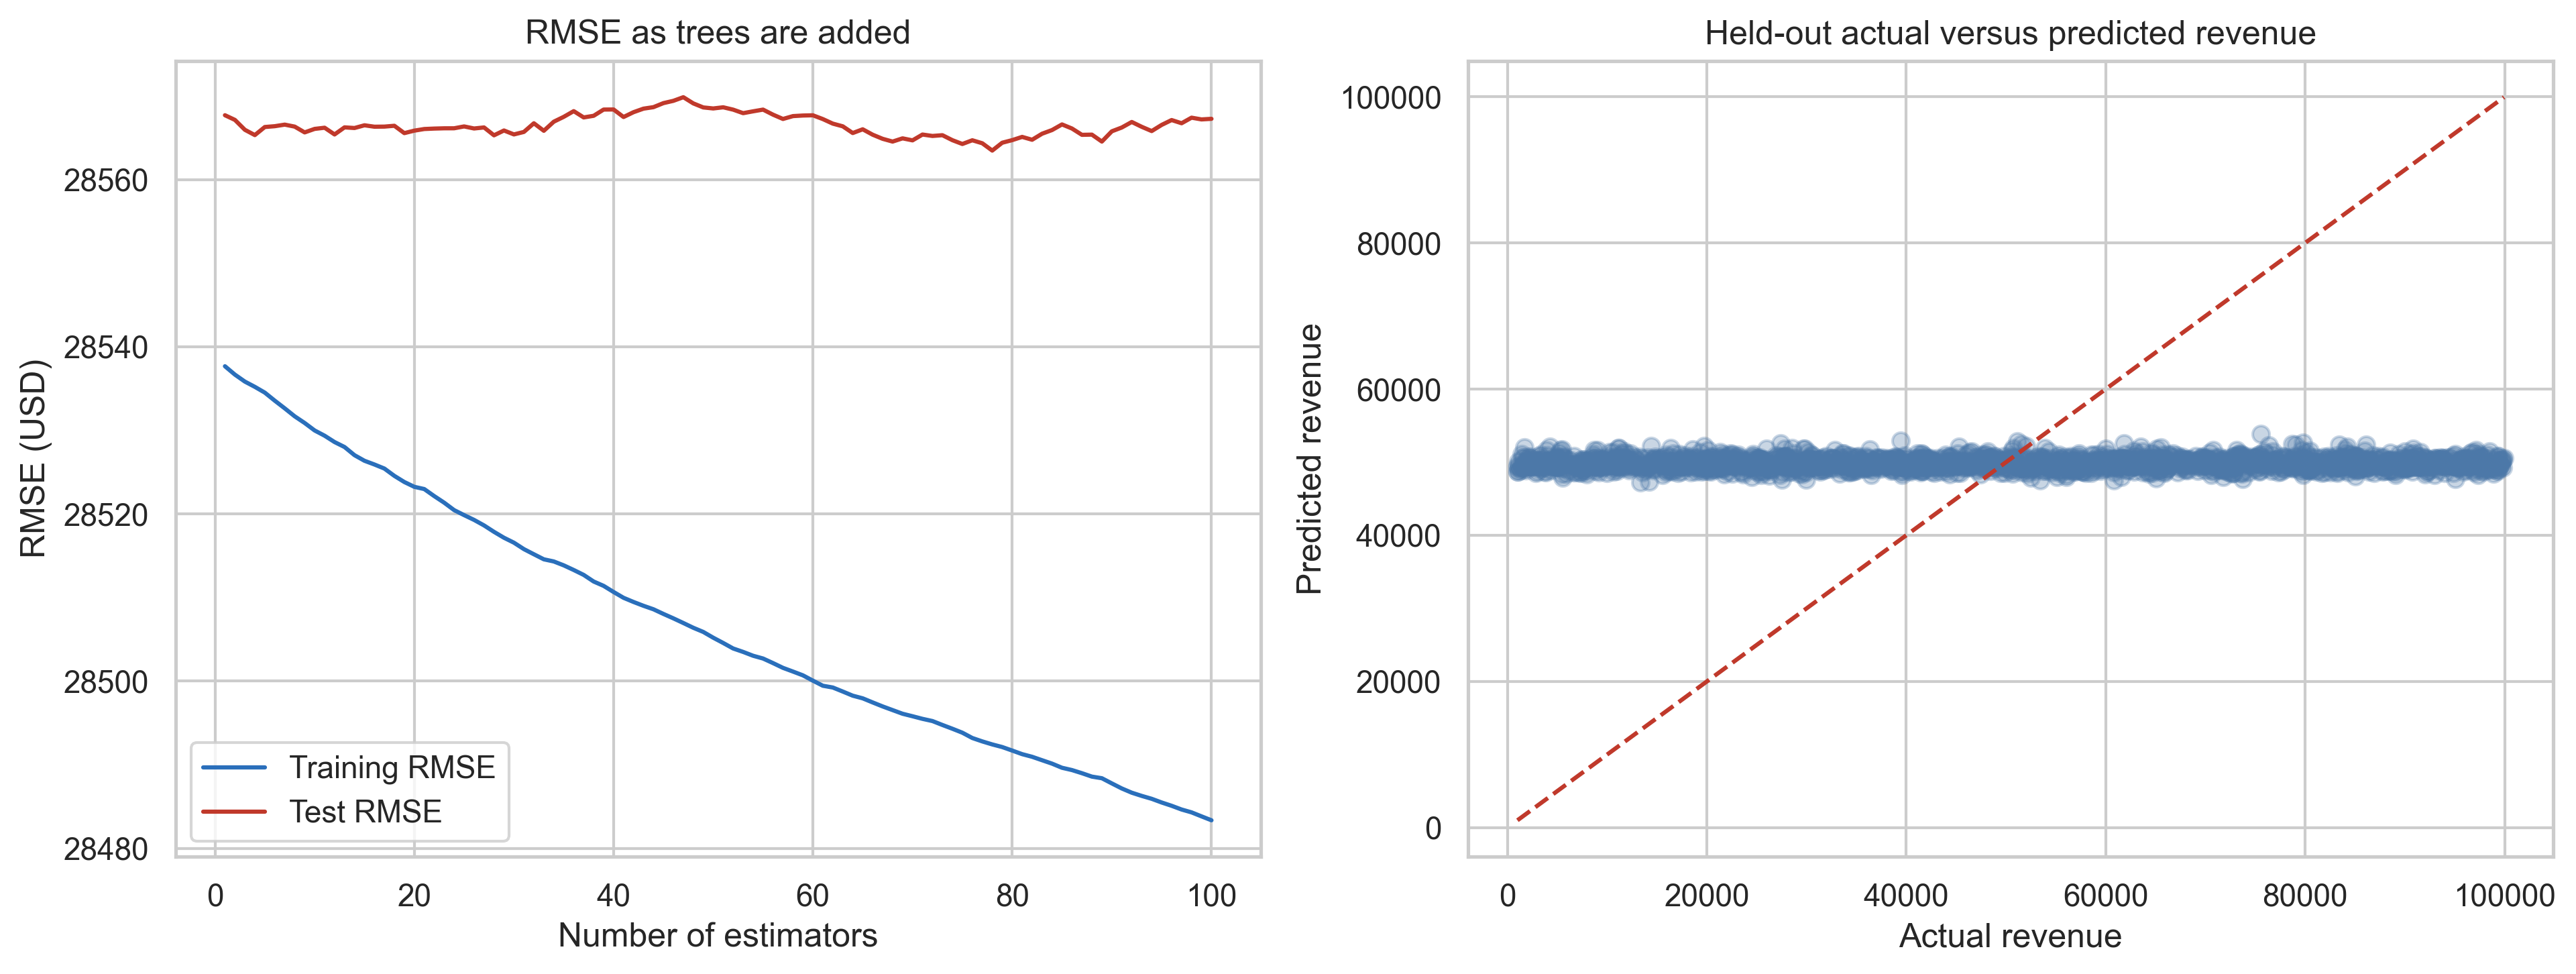

In [7]:
# Compare staged training and test RMSE to see whether adding trees improves generalization.

gbr = best.named_steps['gbr']
train_t = best.named_steps['preprocessor'].transform(X_train)
test_t = best.named_steps['preprocessor'].transform(X_test)
stages = np.arange(1, gbr.n_estimators + 1)
train_curve = [mean_squared_error(y_train, z) ** 0.5 for z in gbr.staged_predict(train_t)]
test_curve = [mean_squared_error(y_test, z) ** 0.5 for z in gbr.staged_predict(test_t)]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(stages, train_curve, label='Training RMSE', color='#2A6FBB')
axes[0].plot(stages, test_curve, label='Test RMSE', color='#C0392B')
axes[0].set(title='RMSE as trees are added', xlabel='Number of estimators', ylabel='RMSE (USD)')
axes[0].legend()
axes[1].scatter(y_test, pred, alpha=0.3, color='#4C78A8')
lim = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
axes[1].plot(lim, lim, '--', color='#C0392B')
axes[1].set(title='Held-out actual versus predicted revenue', xlabel='Actual revenue', ylabel='Predicted revenue')
plt.tight_layout()
plt.show()


### Overfitting diagnostic

The staged curves compare training and test RMSE as trees are added. Training error can continue falling simply because the ensemble gains flexibility; the relevant question is whether test error falls too. Here, the conservative selected model avoids a large generalization gain from extra trees, and the actual-versus-predicted plot shows predictions concentrated around the mean rather than tracking individual revenue values. Together with cross-validation and the held-out comparison, this supports the conclusion that more complexity would not solve the missing predictive signal.


### Step 4.3 — Inspect model feature importance cautiously

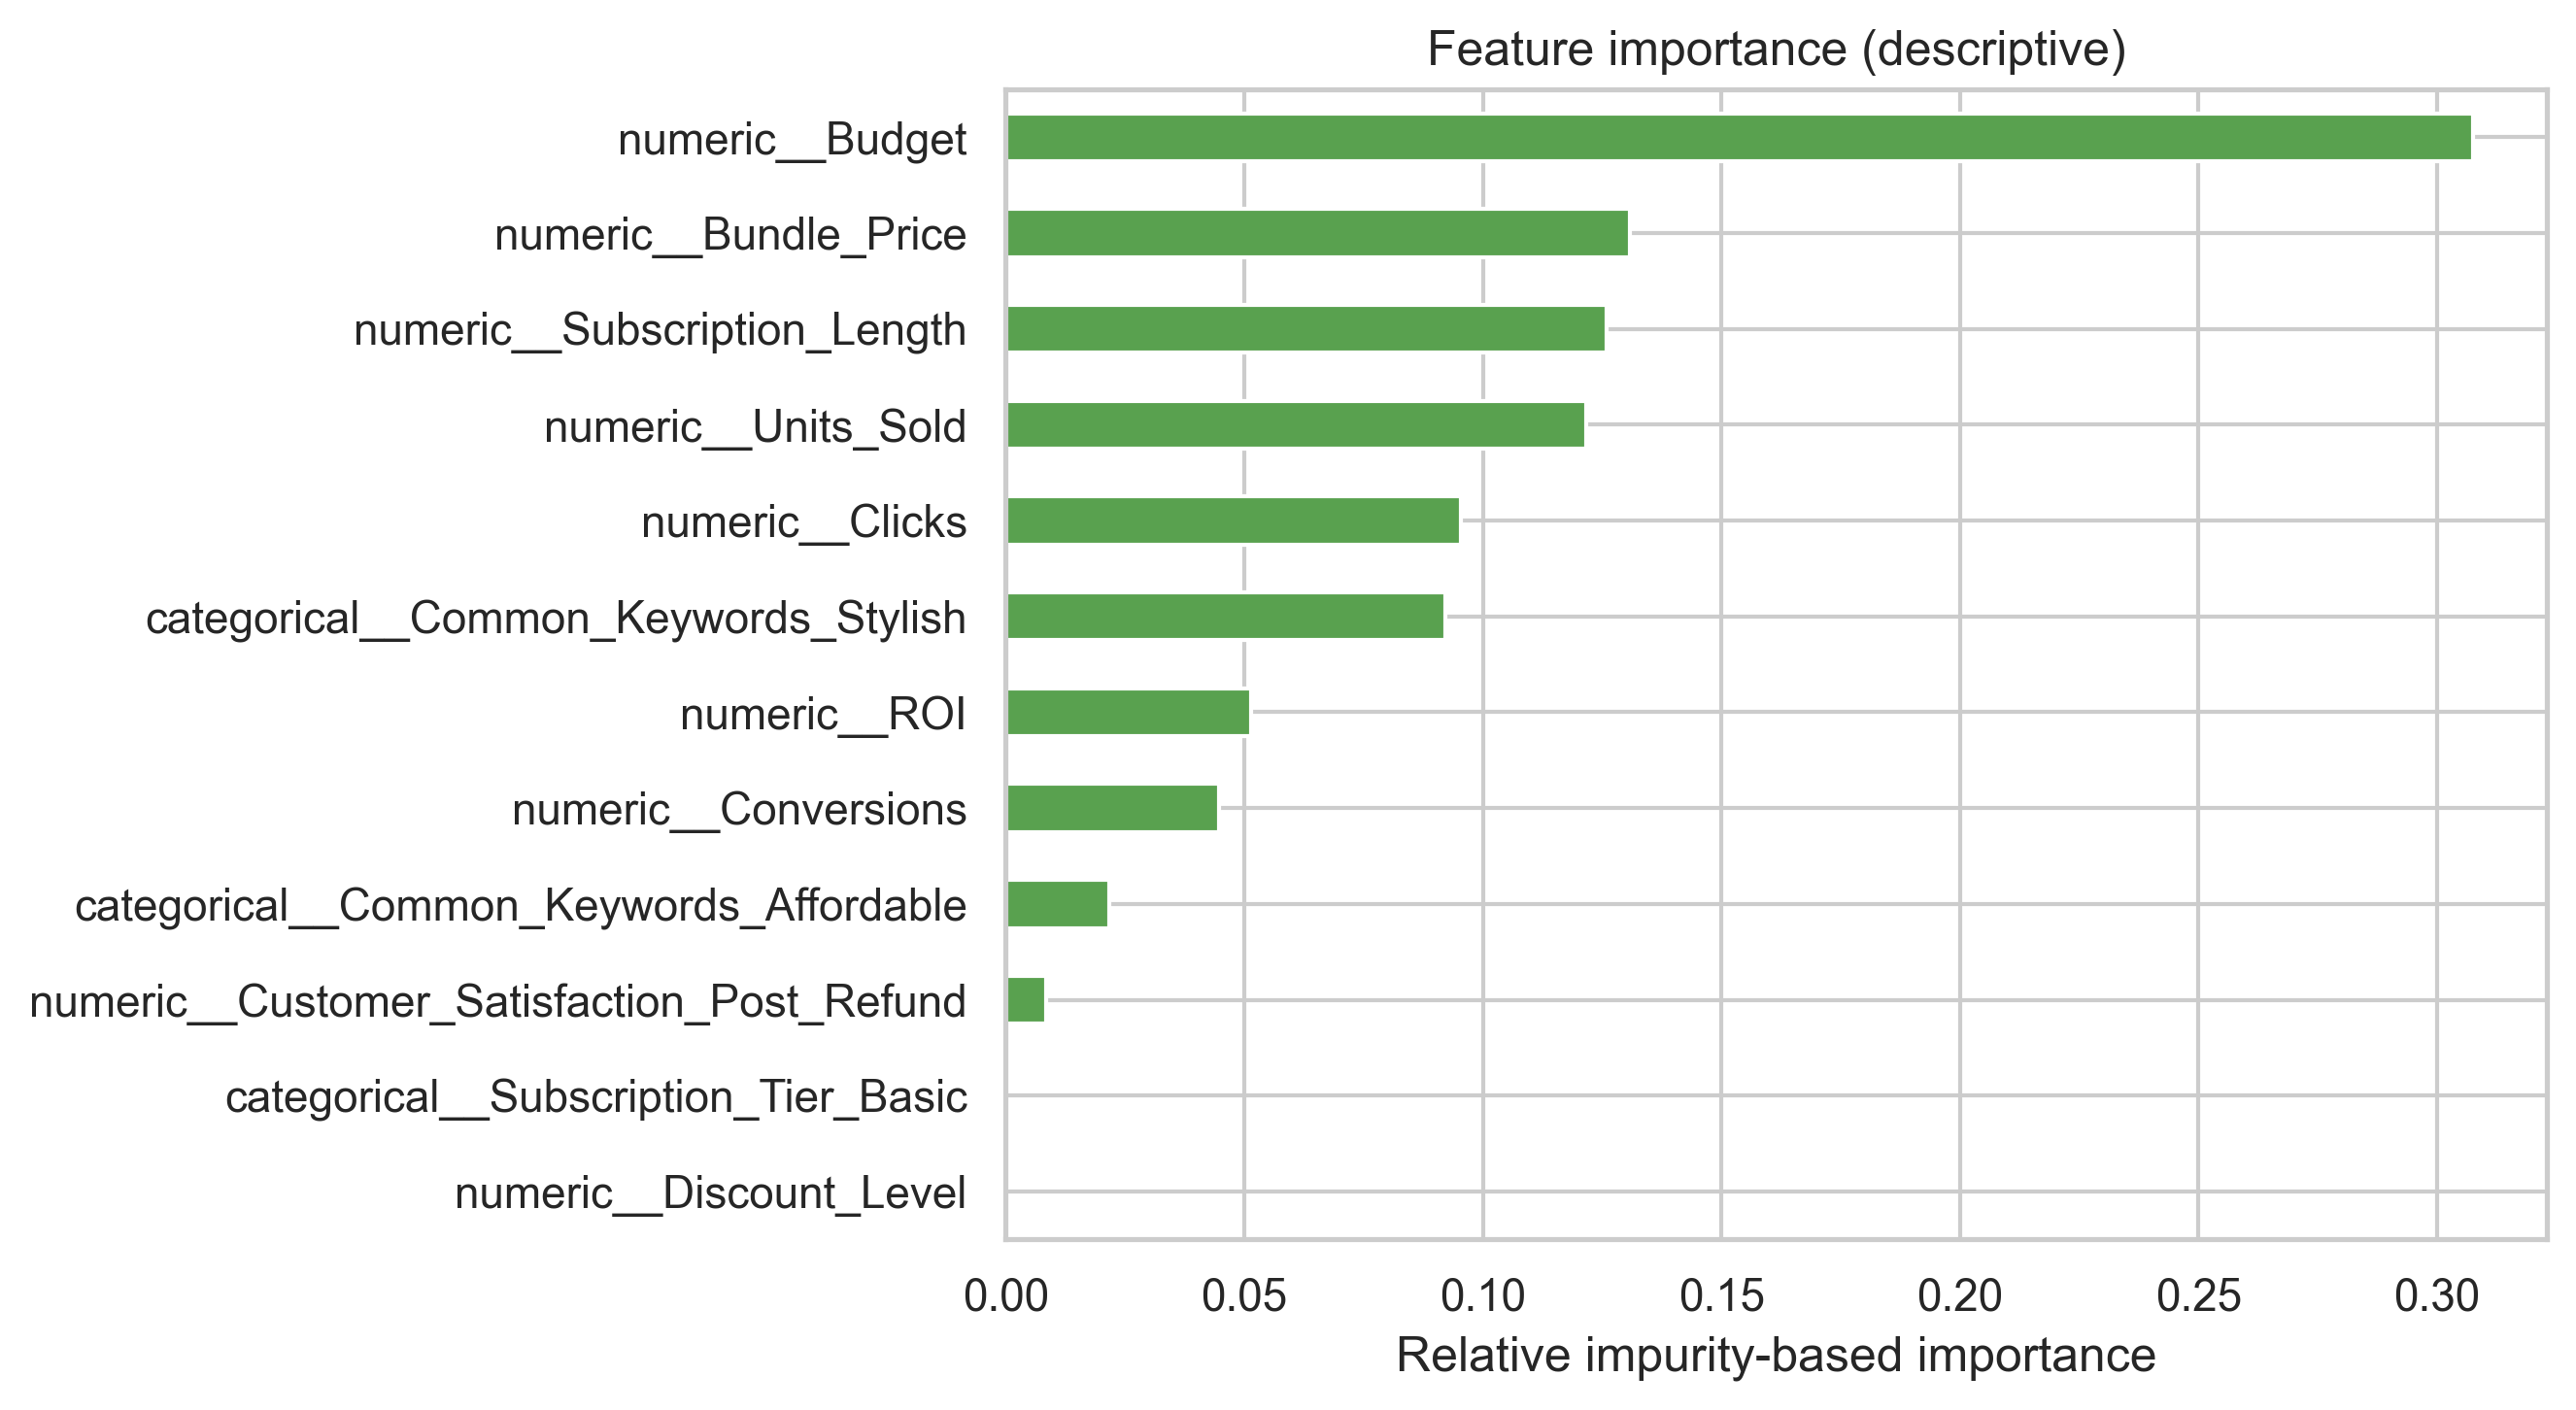

Importance is descriptive, not causal. Weak validation performance makes rankings especially vulnerable to noise.


In [8]:
# Importance rankings describe split usage; they do not establish causation or stable predictive value.

names = best.named_steps['preprocessor'].get_feature_names_out()
imp = pd.Series(gbr.feature_importances_, index=names).sort_values(ascending=False).head(12)
plt.figure(figsize=(9, 5))
imp.sort_values().plot(kind='barh', color='#59A14F')
plt.title('Feature importance (descriptive)')
plt.xlabel('Relative impurity-based importance')
plt.tight_layout()
plt.show()
print('Importance is descriptive, not causal. Weak validation performance makes rankings especially vulnerable to noise.')


### Feature-importance interpretation

Impurity-based importance records how often and how effectively a feature is used for splits in this fitted ensemble. It is not causal evidence, and with near-baseline held-out performance it is not a reliable ranking of revenue drivers. The chart is retained as a transparent model diagnostic, while the conclusion remains focused on validation performance rather than an attractive-looking feature list.


## 5. Week 9 interpretation

The best cross-validated configuration was deliberately conservative: learning rate = 0.03, 100 estimators, depth = 1, minimum leaf size = 20, and subsample = 0.70. Its mean CV RMSE was **$28,546.57**. On the untouched test set, gradient boosting achieved RMSE = **$28,567.27**, MAE = **$24,718.46**, and R² = **−0.001**. The mean-revenue baseline had almost the same RMSE (**$28,567.79**) and slightly lower MAE (**$24,717.33**).

This is near-baseline performance: boosting did not uncover a generalizable revenue relationship in the supplied attributes. The shallow 100-tree model also performed best in cross-validation; more trees or deeper trees increased the gap between training and validation RMSE without improving the test result. This is evidence of limited signal and increasing model complexity, not a reason to report an inflated model score.

The regularization choices—shallow trees, minimum leaf size, row subsampling, conservative learning rate, and cross-validation—were expected to reduce variance. They cannot create predictive signal that is absent from synthetic data; this validated negative result is therefore a supported model-feasibility finding.

## 6. Week 9 “Think About It” answers

**Similarity to random forest:** Both are tree-based ensembles that can capture nonlinear patterns and interactions.

**Difference from random forest:** Random forest builds independent trees in parallel and averages them. Gradient boosting builds trees sequentially, with each tree fitting residual error from the existing ensemble.

**Small learning rate:** It makes smaller updates and generally needs more trees. With enough estimators it can generalize better by moving gradually toward a solution; with too few trees it can underfit. Learning rate and number of estimators must be tuned together.

## Rubric evidence for this week: Gradient Boosting

**Project relevance and potential impact.** This analysis tests whether the available campaign, product, customer, and promotional attributes can forecast continuous revenue. A useful forecast could support planning and budget allocation; a validated lack of forecastability prevents a team from relying on misleading predictions.

**EDA role.** The audit found complete data and exposed unique IDs that would enable memorization. The revenue distribution and near-zero simple correlations set a cautious expectation that a nonlinear model must prove its value on unseen campaigns.

**Metrics and tuning.** Five-fold cross-validated RMSE selected the Gradient Boosting configuration. Learning rate controls the size of each sequential update; estimators control the number of trees; depth and minimum leaf size control tree complexity; and subsampling adds regularization. Held-out RMSE and MAE measure dollar error, while R² measures improvement over predicting the mean.

**Overfitting safeguards and result.** The test set was held out before tuning; ID fields were removed; trees were intentionally shallow; leaf size, subsampling, learning rate, and estimator count were tuned with CV; and staged train/test curves were inspected. The conservative model had nearly identical held-out RMSE to the mean-revenue baseline and R² of about −0.001. These safeguards revealed limited predictive signal rather than allowing added complexity to inflate a training result.

**Expected and unexpected finding.** More trees were expected to reduce training error. It was unexpected that the flexible ensemble could not meaningfully beat the baseline despite 10,000 records. This is a supported negative feasibility result: the supplied synthetic attributes do not support reliable revenue forecasting.

**AI-use documentation.** Generative AI (OpenAI Codex/ChatGPT) was used to assist with code formatting and explanatory prose. The student reviewed the data, modeling choices, executed outputs, conclusions, and citations, and remains responsible for the submission.


## 7. Week 9 submission checklist and sources

This notebook covers gradient boosting regression, learning rate, number of estimators, tree depth, regularization through leaf size and subsampling, cross-validation, RMSE/MAE/R², baseline comparison, overfitting diagnostics, four figures, and the required reflection answers.

### Sources

- Scikit-learn Developers. (2026). *Ensembles: Gradient boosting, random forests, bagging, voting, stacking*. https://scikit-learn.org/stable/modules/ensemble.html
- Scikit-learn Developers. (2026). *GradientBoostingRegressor*. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html
- Shah, I. A. (2024). *Marketing and Product Performance Dataset* [Data set]. Kaggle. https://www.kaggle.com/datasets/imranalishahh/marketing-and-product-performance-dataset